# 05 — Habitat segmentation (unsupervised baseline)

No NIR, so no NDVI. We segment on **three orthogonal ecological axes** built from
what we have: **ExG** (excess green, an RGB greenness index), **brightness**, and the
**corrected CHM** (height) — the discriminator the poster never used for mapping.

KMeans finds natural clusters (unsupervised); we name them from their feature
centroids with a transparent rule (CHM ≥ 3 m → forest canopy; else ExG ≥ 0.05 →
low vegetation; else → bare soil; water only if a dark/flat/low cluster exists).
This is a **preliminary** product — a defensible first map and a guide for any later
supervised model — not a validated classifier.

Reliable class set: **forest canopy, low vegetation, bare soil, water**. Trails
(shape) and wetland (moisture gradient) are weak in RGB → handled later.

**Inputs:** `data/{talar,pastizal}_ortomosaico.tif`, `outputs/04_chm/*` /
`outputs/03_corrected/pastizal_dtm_0p5m.tif`-derived CHMs.
**Outputs:** `outputs/05_segmentation/` — cluster + habitat rasters, class-area
table, figures.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.plot import plotting_extent

from drone_reserve.segment import (
    build_feature_stack, cluster_kmeans, cluster_centroids,
    assign_classes, apply_class_map, write_label_raster, CLASS_NAMES,
)

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent; break
else:
    raise RuntimeError("repo root not found")

DATA = REPO / "data"
CHM  = REPO / "outputs" / "04_chm"
OUT  = REPO / "outputs" / "05_segmentation"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True); FIGS.mkdir(parents=True, exist_ok=True)

# Per-zone inputs: ortho + the canopy-height model on the 0.5 m grid.
ZONES = {
    "talar":    {"ortho": DATA / "talar_ortomosaico.tif",
                  "chm":   CHM / "talar_chm_corrected_0p5m.tif"},
    "pastizal": {"ortho": DATA / "pastizal_ortomosaico.tif",
                  "chm":   CHM / "pastizal_chm_0p5m.tif"},
}
K = 6  # clusters; merged down to the named classes via the centroid rule
CLASS_COLORS = {0: "#1b7837", 1: "#a6dba0", 2: "#d8b365", 3: "#2c7fb8"}  # forest/lowveg/bare/water
print("OK")

OK


## Cluster each zone and name the clusters

For each zone: build the feature stack, KMeans, inspect centroids, apply the rule,
write cluster + habitat rasters, and tally class areas.

In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
stacks, centroids, classmaps, areas = {}, {}, {}, []
FOREST_CHM = 3.0  # m — measured tall-canopy threshold (height is measured, so use it directly)
for zone, paths in ZONES.items():
    st = build_feature_stack(paths["ortho"], paths["chm"])
    labels = cluster_kmeans(st, k=K)
    cen = cluster_centroids(st, labels)
    mapping = assign_classes(cen, chm_forest=FOREST_CHM)  # ExG>=0.05 low veg; else bare/dry
    classes = apply_class_map(labels, mapping)
    # Override: any pixel with measured CHM >= FOREST_CHM is forest canopy, regardless of
    # which spectral cluster it landed in. Ties the forest class to the measured height
    # and stops KMeans from scattering tall-canopy pixels into low classes.
    with rasterio.open(paths["chm"]) as src:
        chm = src.read(1); cnd = src.nodata
    tall = np.isfinite(chm) & (chm != cnd) & (chm >= FOREST_CHM) & (classes >= 0)
    classes[tall] = 0
    stacks[zone] = (st, labels, classes)
    centroids[zone] = cen.assign(class_id=[mapping[c] for c in cen.index],
                                 class_name=[CLASS_NAMES[mapping[c]] for c in cen.index])
    write_label_raster(labels, st.profile, OUT / f"{zone}_clusters_0p5m.tif")
    write_label_raster(classes, st.profile, OUT / f"{zone}_habitat_0p5m.tif")
    px_ha = abs(st.profile["transform"].a) * abs(st.profile["transform"].e) / 10_000
    for cid, cname in CLASS_NAMES.items():
        n = int((classes == cid).sum())
        if n:
            areas.append({"zone": zone, "class": cname, "area_ha": round(n * px_ha, 2)})
    print(f"\n=== {zone} — cluster centroids + assigned class (pre-CHM-override) ===")
    print(centroids[zone].to_string())

area_tbl = pd.DataFrame(areas).pivot(index="class", columns="zone", values="area_ha").fillna(0)
print("\n=== Class area (ha), forest = measured CHM >= 3 m ==="); area_tbl

C:\Users\paco_\miniforge3\envs\drone-reserve\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



=== talar — cluster centroids + assigned class (pre-CHM-override) ===
          ExG  brightness   CHM  n_pixels  area_ha  class_id         class_name
cluster                                                                        
2       0.032     161.642 5.823     62338    1.558         0      forest canopy
1       0.122     138.950 1.710     53007    1.325         1     low vegetation
4       0.004     166.622 1.298    135589    3.390         2  bare / dry ground
5       0.042     138.690 1.203     58716    1.468         2  bare / dry ground
3       0.012     197.368 0.365     59509    1.488         2  bare / dry ground
0       0.070     166.982 0.319    105211    2.630         1     low vegetation



=== pastizal — cluster centroids + assigned class (pre-CHM-override) ===
          ExG  brightness   CHM  n_pixels  area_ha  class_id         class_name
cluster                                                                        
3       0.037     159.968 6.204     56577    1.414         0      forest canopy
1       0.130     138.193 1.268     60288    1.507         1     low vegetation
5       0.055     136.986 0.844     75180    1.879         1     low vegetation
4       0.012     197.454 0.535     64404    1.610         2  bare / dry ground
0       0.017     161.588 0.528    160831    4.021         2  bare / dry ground
2       0.074     168.975 0.234    117807    2.945         1     low vegetation

=== Class area (ha), forest = measured CHM >= 3 m ===


zone,pastizal,talar
class,,
bare / dry ground,5.470,5.860
forest canopy,2.000,2.400
low vegetation,5.910,3.600


## Maps: ortho vs habitat classes

C:\Users\paco_\AppData\Local\Temp\ipykernel_54692\1645163524.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / f"{zone}_habitat.png", dpi=140); fig.show()


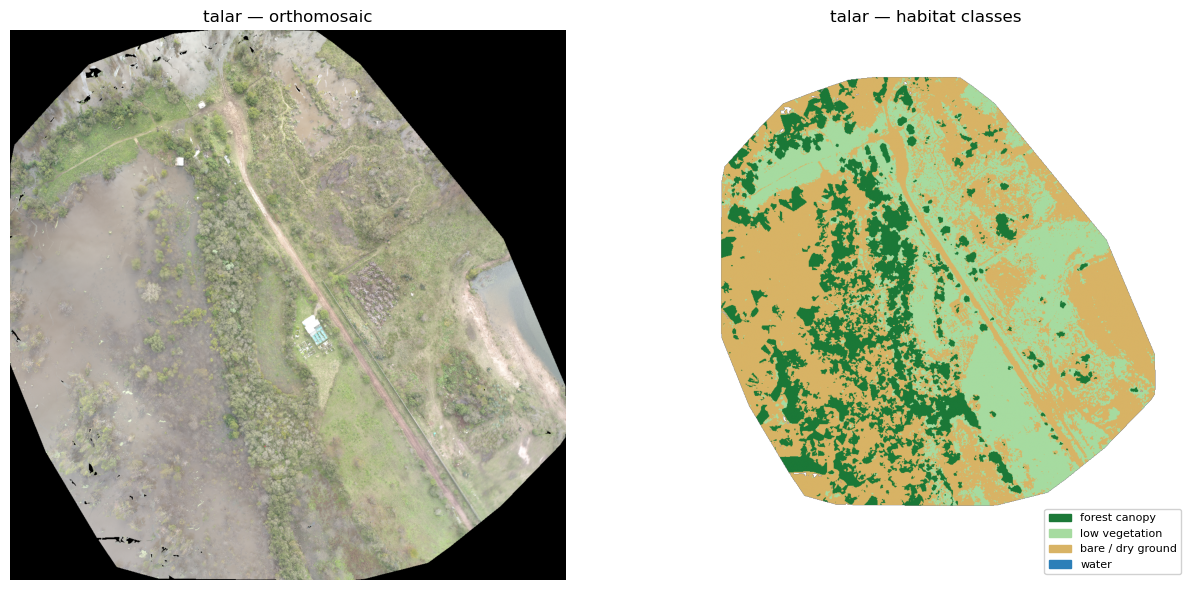

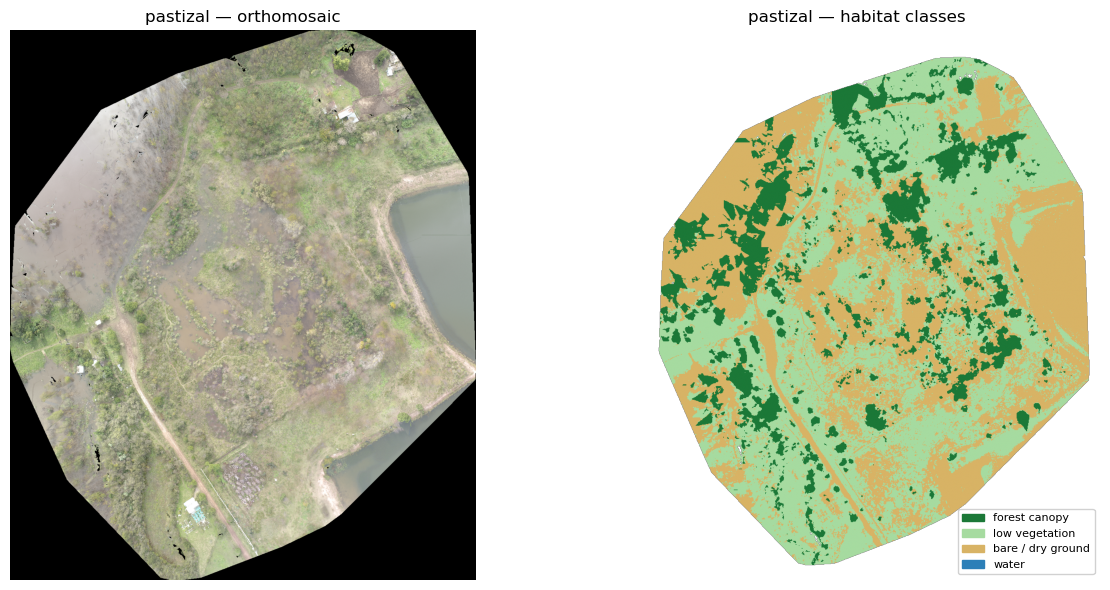

In [3]:
hab_cmap = ListedColormap([CLASS_COLORS[i] for i in sorted(CLASS_COLORS)])
for zone, paths in ZONES.items():
    st, labels, classes = stacks[zone]
    with rasterio.open(paths["chm"]) as src:
        ext = plotting_extent(src)
    # ortho RGB thumbnail (downsampled read)
    with rasterio.open(paths["ortho"]) as o:
        scale = max(1, o.width // 1200)
        rgb = o.read([1, 2, 3], out_shape=(3, o.height // scale, o.width // scale))
        rgb = np.transpose(rgb, (1, 2, 0)) / 255.0
        oext = plotting_extent(o)
    hab = np.where(classes < 0, np.nan, classes).astype(float)
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    axes[0].imshow(rgb, extent=oext); axes[0].set_title(f"{zone} — orthomosaic")
    im = axes[1].imshow(hab, extent=ext, cmap=hab_cmap, vmin=0, vmax=3)
    axes[1].set_title(f"{zone} — habitat classes")
    for ax in axes: ax.set_axis_off()
    handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[i]) for i in sorted(CLASS_COLORS)]
    axes[1].legend(handles, [CLASS_NAMES[i] for i in sorted(CLASS_COLORS)],
                   loc="lower right", fontsize=8, framealpha=0.9)
    fig.tight_layout(); fig.savefig(FIGS / f"{zone}_habitat.png", dpi=140); fig.show()

## Sanity check (no labels, so qualitative)

The 11 field trees should fall in **forest canopy** or **low vegetation**, not bare/water.
(Forest canopy is defined as measured CHM ≥ 3 m, so its area equals the CHM ≥ 3 m area by
construction — the check below is the per-tree class assignment.)

In [4]:
trees = gpd.read_file(DATA / "Trees.shp", encoding="latin1")
with rasterio.open(OUT / "talar_habitat_0p5m.tif") as src:
    nd = src.nodata
    vals = [v[0] for v in src.sample([(g.x, g.y) for g in trees.geometry])]
trees_chk = trees[["id", "Species", "RF height"]].copy()
trees_chk["habitat"] = [CLASS_NAMES.get(v, "nodata") if v != nd else "nodata" for v in vals]
print(trees_chk.to_string(index=False))

veg = trees_chk["habitat"].isin(["forest canopy", "low vegetation"]).sum()
print(f"\nTrees in a vegetation class: {veg}/11")
print(f"Talar forest-canopy area (= CHM>=3 m): {area_tbl.loc['forest canopy', 'talar']:.2f} ha")

 id       Species  RF height           habitat
  2 Sauce Criollo     10.440     forest canopy
  1     Morus sp.      4.000     forest canopy
  3          Tala      6.630     forest canopy
  4          Tala     10.210     forest canopy
  5    Fumo Bravo      5.870     forest canopy
  6          Tala      7.160     forest canopy
  7         OmbÃº      5.720     forest canopy
  8 Cola de Zorro      2.440 bare / dry ground
  9        Chilca      2.200    low vegetation
 10        Chilca      3.100    low vegetation
 11         Sauce      5.790     forest canopy

Trees in a vegetation class: 10/11
Talar forest-canopy area (= CHM>=3 m): 2.40 ha


In [5]:
area_tbl.to_csv(OUT / "class_areas_ha.csv")
for zone in ZONES:
    centroids[zone].to_csv(OUT / f"{zone}_cluster_centroids.csv")
print("Wrote:")
for p in [OUT / "class_areas_ha.csv",
          *[OUT / f"{z}_clusters_0p5m.tif" for z in ZONES],
          *[OUT / f"{z}_habitat_0p5m.tif" for z in ZONES]]:
    print(f"  {p}")

Wrote:
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\05_segmentation\class_areas_ha.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\05_segmentation\talar_clusters_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\05_segmentation\pastizal_clusters_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\05_segmentation\talar_habitat_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\05_segmentation\pastizal_habitat_0p5m.tif


## Findings & caveats

- **Class areas (ha):** talar — forest canopy 2.4, low vegetation 3.6, bare/dry ground 5.9;
  pastizal — forest canopy 2.0, low vegetation 5.9, bare/dry ground 5.5. Totals match the
  flight footprints. Pastizal having more low vegetation and the talar more forest canopy
  matches the field description (grassland vs forest).
- **Qualitative validation:** 10/11 field trees fall in a vegetation class; the habitat map's
  forest patches line up with the dense-tree areas in the ortho. The one miss — *Cola de
  Zorro* (a straw-coloured *Cortaderia* tussock) → bare/dry ground — is exactly the RGB limit.
- **Forest canopy is defined by measured CHM ≥ 3 m**, not by the cluster, so its area equals
  the CHM ≥ 3 m area and doesn't depend on KMeans grouping. Height is the reliable axis here.
- **"bare / dry ground" is deliberately broad** — with RGB+ExG and no NIR, true bare soil,
  dry/senescent grass, and leaf litter all read as low-greenness ground and can't be split.
- **No water** cluster appeared in either zone (no open water in the flown areas).
- **Unsupervised + preliminary:** names come from a transparent centroid rule, not labels —
  there is no accuracy figure. This is a first map and a guide for a later supervised model
  (Random Forest with QGIS labels) if higher rigour / wetland & trails are needed.
- Built at 0.5 m on the CHM grid; ortho streamed via WarpedVRT (no full-res load).